# Mutual Fund Analytics Platform
## Exploratory Data Analysis (EDA)

**Project:** Bluestock Fintech Capstone

**Student:** Sandeep Shekhawat

**Date:** June 2026

**Objective:**
Analyze mutual fund datasets to identify investment trends, fund performance, investor behavior, and portfolio insights using Python visualizations.


# 1. Import Required Libraries

In [459]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import kaleido
plt.style.use("ggplot")

# 2. Load Datasets

In [460]:
fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/05_category_inflows.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


# 3. Dataset Overview

# 4. NAV Trend Analysis

### Objective

Analyze the daily NAV movement of all mutual fund schemes between 2022 and 2026.

### Business Question

How have the mutual fund NAVs changed over time, and what market trends can be observed?

In [461]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [462]:
# Average NAV of all schemes for each day

avg_nav = (
    nav
    .groupby("date")["nav"]
    .mean()
    .reset_index()
)

avg_nav["date"] = pd.to_datetime(avg_nav["date"])

avg_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


In [463]:
fig = px.line(
    avg_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Trend of Indian Mutual Funds (2022–2026)"
)



# Shade Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

# Shade Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.12,
    line_width=0
)

# Bull Run Annotation
fig.add_annotation(
    x="2023-07-01",
    y=355,
    text="📈 2023 Bull Run",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-40,
    font=dict(size=14, color="green")
)

# Market Correction Annotation
fig.add_annotation(
    x="2024-03-01",
    y=345,
    text="📉 2024 Market Correction",
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=-40,
    font=dict(size=14, color="red")
)
fig.update_layout(

    template="plotly_white",

    height=650,
    width=900
)

fig.show()

### Observation

The average NAV increased steadily from approximately 207 in 2022 to around 358 in 2026, indicating sustained long-term growth in the mutual fund market. The highlighted periods represent the 2023 bull run and the temporary market correction during early 2024.

# 4.2 Daily NAV Trend of All 40 Mutual Fund Schemes

## Objective

Visualize the daily Net Asset Value (NAV) movement of all 40 mutual fund schemes from 2022–2026.

## Business Purpose

This interactive chart allows comparison of individual scheme performance over time. Since all 40 schemes are displayed, users can zoom, pan, and selectively view specific funds using the legend.

In [464]:
# Merge NAV history with Fund Master

nav_all = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Sort data
nav_all = nav_all.sort_values(["scheme_name", "date"])

nav_all.head()

,amfi_code,date,nav,scheme_name
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth


In [465]:
fig = px.line(
    nav_all,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All 40 Mutual Fund Schemes (2022–2026)",
    hover_data=["amfi_code"]
)

fig.update_layout(

    template="plotly_white",

    height=750,
width=1200,
    title_x=0.5,

    xaxis_title="Date",

    yaxis_title="Net Asset Value (NAV)",

    legend_title="Mutual Fund Scheme",

    hovermode="x unified"
)
# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0
)

# 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.08,
    line_width=0
)

# Bull Run Annotation
fig.add_annotation(
    x="2023-07-01",
    y=nav_all["nav"].max()*0.95,
    text="📈 2023 Bull Run",
    showarrow=True,
    arrowhead=2,
    font=dict(size=13, color="green")
)

# Market Correction Annotation
fig.add_annotation(
    x="2024-03-01",
    y=nav_all["nav"].max()*0.90,
    text="📉 2024 Market Correction",
    showarrow=True,
    arrowhead=2,
    font=dict(size=13, color="red")
)
fig.show()

# 5. Assets Under Management (AUM) Analysis

In [466]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [467]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

### 5. Assets Under Management (AUM) Analysis

**Objective:**
Analyze the growth of Assets Under Management (AUM) for major fund houses from 2022 to 2025.

**Business Question:**
Which fund houses have the highest AUM and how has it changed over time?

In [468]:
# Convert date column to datetime

aum["date"] = pd.to_datetime(aum["date"])

# Extract Year

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


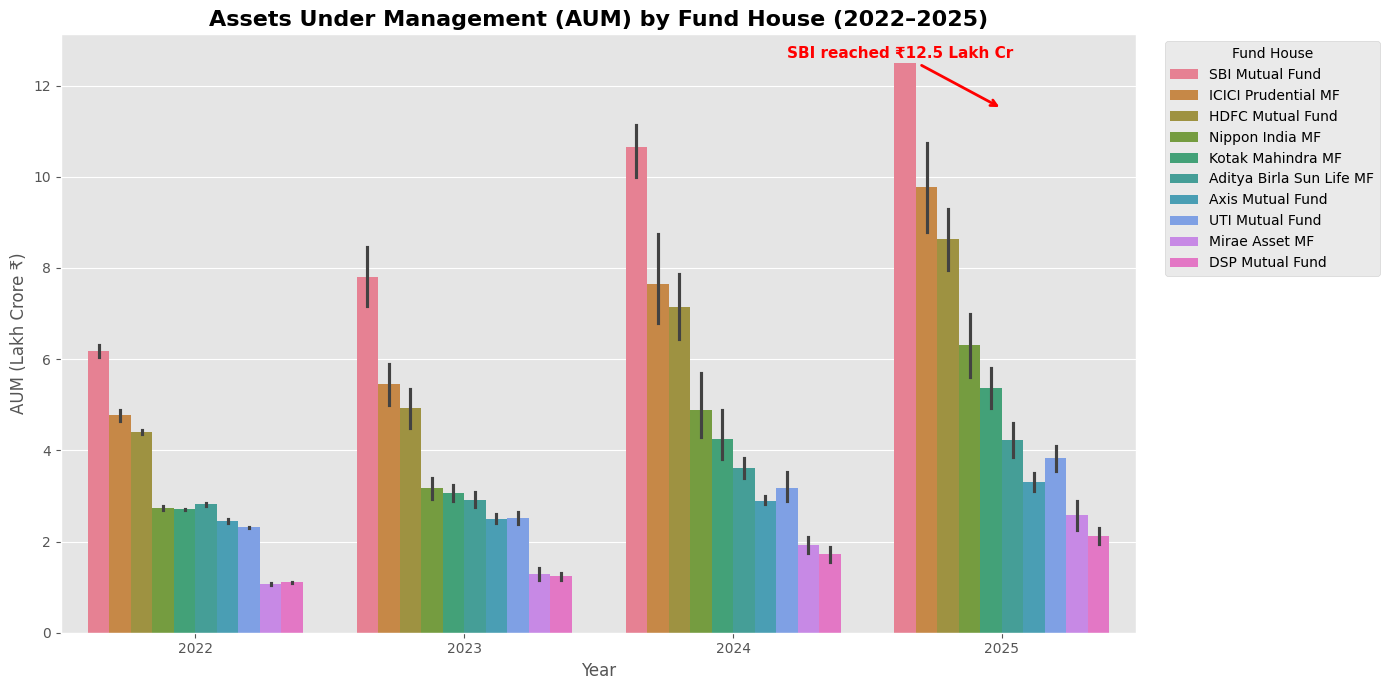

In [469]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Assets Under Management (AUM) by Fund House (2022–2025)",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Year", fontsize=12)

plt.ylabel("AUM (Lakh Crore ₹)", fontsize=12)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.annotate(
    "SBI reached ₹12.5 Lakh Cr",
    xy=(3, 11.5),
    xytext=(2.2, 12.6),
    arrowprops=dict(arrowstyle="->", color="red", lw=2),
    fontsize=11,
    color="red",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

- SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) from 2022 to 2025.
- All major fund houses showed steady year-on-year growth, indicating increasing investor participation.
- SBI crossed approximately ₹12.5 lakh crore AUM in 2025, significantly outperforming other AMCs.
- HDFC Mutual Fund and ICICI Prudential MF remained the second and third largest fund houses throughout the analysis period.

### Insight

SBI Mutual Fund maintained the highest AUM among all fund houses,
indicating strong investor confidence.

# 6. SIP Inflow Analysis

In [470]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [471]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

# 6. Monthly SIP Inflow Trend

### Objective

Analyze the monthly SIP inflow trend from January 2022 to December 2025.

### Business Question

How has monthly SIP investment changed over time, and when was the highest SIP inflow recorded?

In [472]:
# Convert month column to datetime

sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [504]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

# Find the highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Add annotation
fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest SIP<br>₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-60,
    font=dict(size=12, color="green")
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    height=650
)


fig.show()

### Business Insight

- Monthly SIP inflows showed a consistent upward trend from 2022 to 2025.
- The highest monthly SIP inflow was recorded in **December 2025**, reaching **₹31,002 crore**.
- The steady increase in SIP contributions indicates growing investor confidence and increasing participation in mutual funds through systematic investments.

### Insight

Monthly SIP inflows steadily increased,
reaching an all-time high in December 2025.

# 7. Category Inflow Analysis

# 7. Category Inflow Heatmap

### Objective

Analyze monthly net inflows across different mutual fund categories.

### Business Question

Which mutual fund categories attracted the highest inflows during different months?

In [505]:
category.head()

,month,category,net_inflow_crore,month_label
0,2024-04-01,Large Cap,2413.0,Apr-24
1,2024-04-01,Mid Cap,3897.0,Apr-24
2,2024-04-01,Small Cap,3533.0,Apr-24
3,2024-04-01,Flexi Cap,4947.0,Apr-24
4,2024-04-01,Large & Mid Cap,4214.0,Apr-24


In [506]:
category.columns

Index(['month', 'category', 'net_inflow_crore', 'month_label'], dtype='object')

In [ ]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


In [479]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create short labels like Apr-24
category["month_label"] = category["month"].dt.strftime("%b-%y")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

# Sort columns chronologically
month_order = (
    category[["month", "month_label"]]
    .drop_duplicates()
    .sort_values("month")["month_label"]
)

heatmap_data = heatmap_data[month_order]

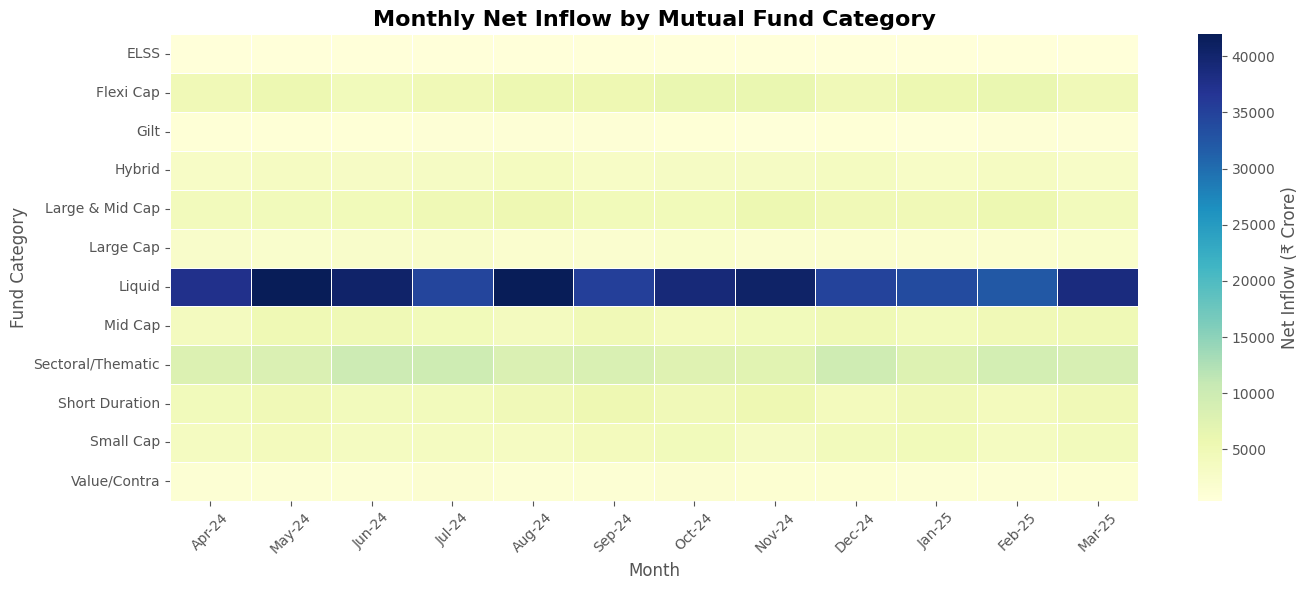

In [480]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Monthly Net Inflow by Mutual Fund Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# 8. Investor Demographics

In [481]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [482]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

### 8.1 Age Group Distribution

**Objective**

Analyze the distribution of investors across different age groups.

**Business Question**

Which age group contributes the largest number of investors?

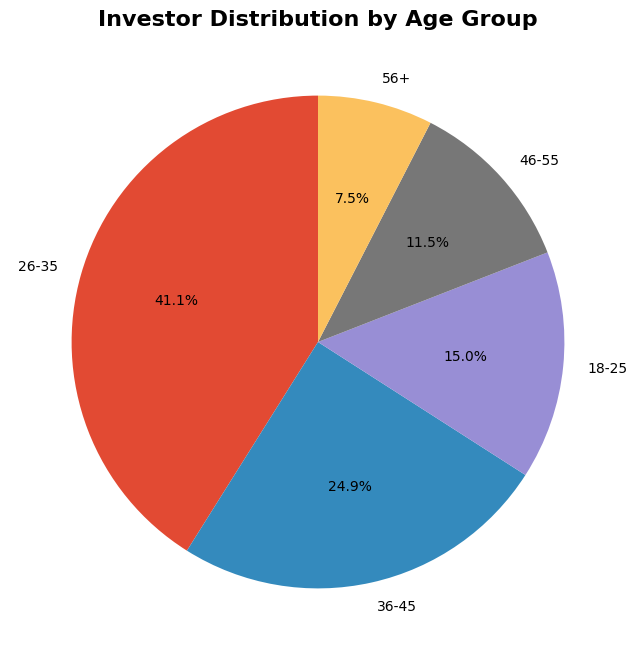

In [483]:
plt.figure(figsize=(8,8))

age_counts = transactions["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Distribution by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.show()

### Business Insight

- The chart shows the proportion of investors across different age groups.
- The largest age group represents the highest participation in mutual fund investments.
- Younger and middle-aged investors generally contribute the majority of SIP investments.

### 8.2 Investment Amount by Age Group

**Objective**

Compare investment amounts across different age groups.

**Business Question**

Which age group generally invests larger amounts?

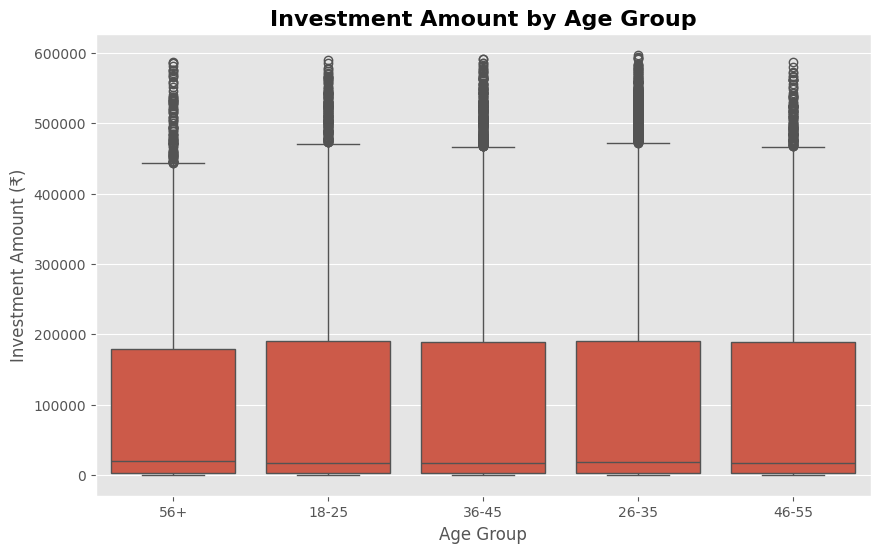

In [484]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "Investment Amount by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.show()

### 8.3 Gender Distribution

**Objective**

Analyze investor participation based on gender.

**Business Question**

What is the gender-wise distribution of mutual fund investors?

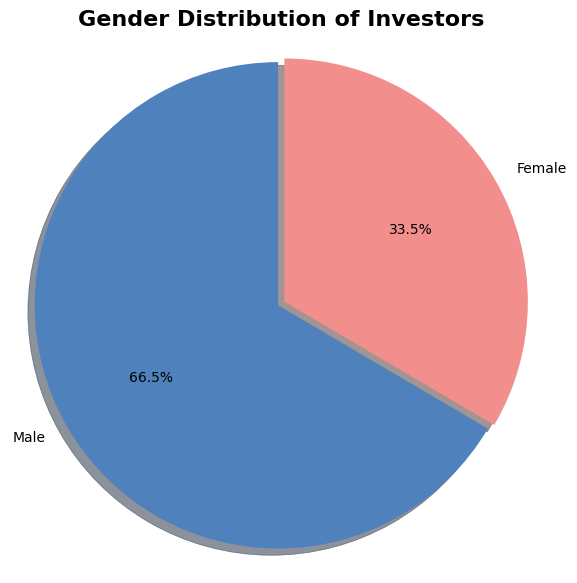

In [485]:
plt.figure(figsize=(7,7))

gender_counts = transactions["gender"].value_counts()

colors = ["#4F81BD", "#F28E8C"]

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=[0.03, 0],
    shadow=True
)

plt.title(
    "Gender Distribution of Investors",
    fontsize=16,
    fontweight="bold"
)

plt.axis("equal")

plt.show()

### Business Insight

- Male investors account for approximately **66.5%** of all investors in the dataset.
- Female investors represent approximately **33.5%** of the investor base.
- The results indicate that male participation is nearly twice that of female participation, highlighting an opportunity for mutual fund companies to increase financial awareness and investment participation among women.

# 9. Geographic Distribution

# 9.1 State-wise Investment Distribution

### Objective

Analyze the total investment amount across different Indian states.

### Business Question

Which states contribute the highest investment amount?

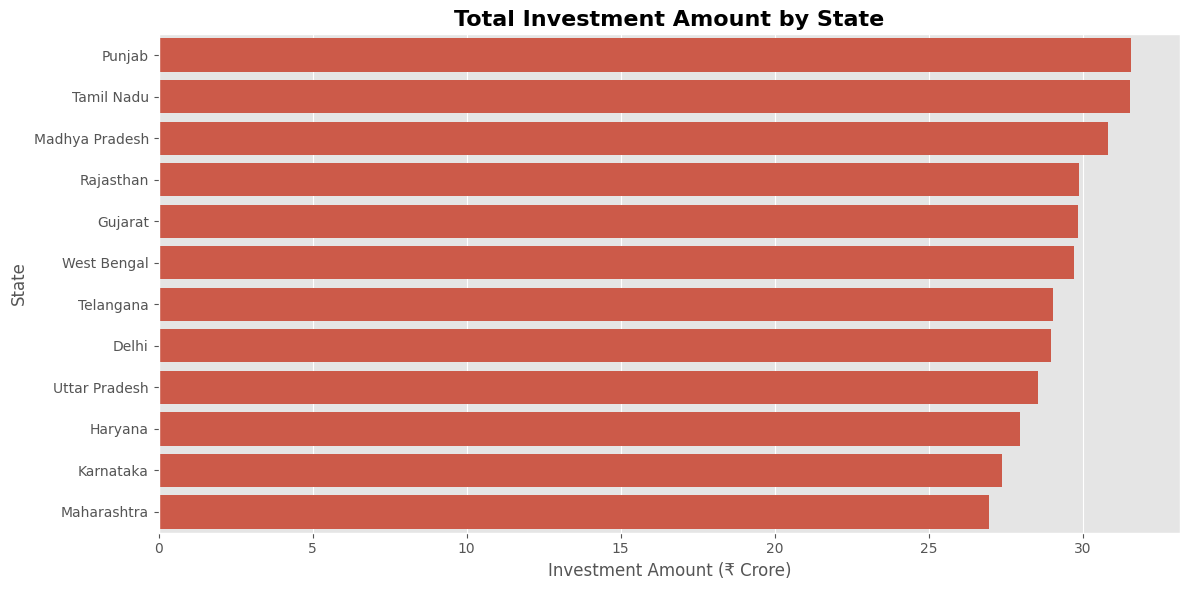

In [486]:
# Total investment amount by state

# Group by state
state_investment = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

# Convert to Crores
state_investment = state_investment / 10000000

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_investment.values,
    y=state_investment.index
)

plt.title(
    "Total Investment Amount by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Investment Amount (₹ Crore)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

### 9.2 T30 vs B30 City Tier Distribution

**Objective**

Compare investor participation between Top 30 (T30) cities and Beyond Top 30 (B30) cities.

**Business Question**

How is mutual fund participation distributed across metropolitan and non-metropolitan cities?

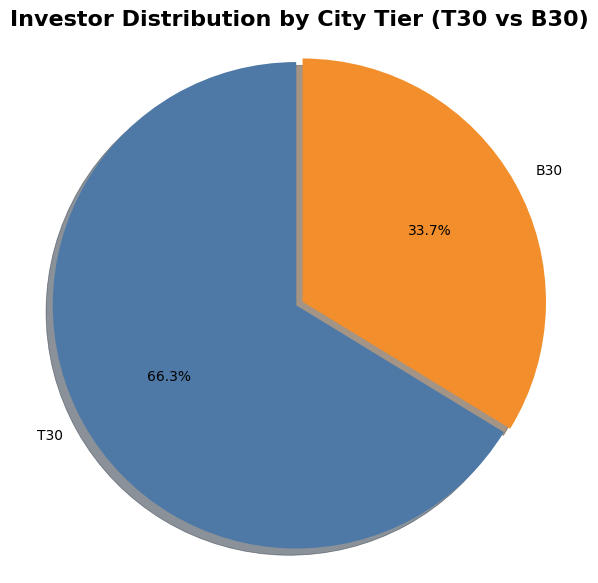

In [487]:
# Count investors by city tier
city_tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

colors = ["#4E79A7", "#F28E2B"]

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03, 0],
    colors=colors,
    shadow=True
)

plt.title(
    "Investor Distribution by City Tier (T30 vs B30)",
    fontsize=16,
    fontweight="bold"
)

plt.axis("equal")

plt.show()

# 10. NAV Return Correlation

# 10. Folio Count Growth Analysis

### Objective

Analyze the growth in mutual fund folio counts over time.

### Business Question

How has the number of mutual fund folios grown between 2022 and 2025?

In [488]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [489]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

In [490]:
# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [491]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folio Count (2022–2025)"
)

# Starting point
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text="Start: 13.26 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-40
)

# Ending point
fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text="End: 26.12 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-40
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Total Folios (Crore)",
    height=650
)

fig.show()

### Business Insight

- The number of mutual fund folios increased steadily from **13.26 crore** in early 2022 to approximately **26.12 crore** by the end of 2025.
- This nearly twofold increase indicates rapid growth in investor participation in the Indian mutual fund industry.
- The consistent upward trend reflects increasing financial awareness and wider adoption of mutual funds.

In [492]:
# Merge NAV with Fund Names

corr_df = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

corr_df.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [493]:
pivot_nav = corr_df.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

pivot_nav.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth,...,Nippon India Large Cap Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,41.8140,38.7466,68.3023,52.5238,78.4622,81.6814,348.7159,...,42.8339,69.1076,58.4174,54.3856,42.1391,96.4565,89.8738,191.0721,119.2905,89.8728
2022-01-04,305.4514,310.6977,38.1545,41.8062,38.4924,68.0566,53.5090,78.5000,80.8239,345.7198,...,42.8033,68.8538,57.3480,54.3474,42.2508,94.6512,88.5495,189.0737,120.6402,90.8724
2022-01-05,306.6324,310.8165,38.1775,41.6865,38.2033,69.1860,54.5737,79.1806,80.6143,343.4795,...,43.0564,69.0511,57.0552,54.6869,42.4374,94.5436,88.0925,188.0701,121.4580,90.1565
2022-01-06,305.9800,310.7719,37.0665,41.2775,38.5825,69.1690,54.5502,78.0831,79.9386,342.1680,...,43.2088,68.4476,56.4224,55.4550,42.5901,93.7944,88.5175,190.4545,125.2386,91.5338
2022-01-07,304.0480,310.8388,37.9845,41.6166,38.9425,67.8877,56.3221,78.4202,80.8723,340.7757,...,42.9585,67.0371,57.2750,55.3692,42.4851,89.6438,91.4235,187.3124,124.1321,90.6762


In [494]:
selected_funds = pivot_nav.iloc[:, :10]

selected_funds.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,41.8140,38.7466,68.3023,52.5238,78.4622,81.6814,348.7159
2022-01-04,305.4514,310.6977,38.1545,41.8062,38.4924,68.0566,53.5090,78.5000,80.8239,345.7198
2022-01-05,306.6324,310.8165,38.1775,41.6865,38.2033,69.1860,54.5737,79.1806,80.6143,343.4795
2022-01-06,305.9800,310.7719,37.0665,41.2775,38.5825,69.1690,54.5502,78.0831,79.9386,342.1680
2022-01-07,304.0480,310.8388,37.9845,41.6166,38.9425,67.8877,56.3221,78.4202,80.8723,340.7757


In [495]:
daily_returns = selected_funds.pct_change()

daily_returns.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.001153,-0.000141,-0.010865,-0.000187,-0.006561,-0.003597,0.018757,0.000482,-0.010498,-0.008592
2022-01-05,0.003866,0.000382,0.000603,-0.002863,-0.007511,0.016595,0.019898,0.008670,-0.002593,-0.006480
2022-01-06,-0.002128,-0.000143,-0.029101,-0.009811,0.009926,-0.000246,-0.000431,-0.013861,-0.008382,-0.003818
2022-01-07,-0.006314,0.000215,0.024766,0.008215,0.009331,-0.018524,0.032482,0.004317,0.011680,-0.004069


In [496]:
correlation_matrix = daily_returns.corr()

correlation_matrix

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,0.012036,0.056952,-0.040309,-0.029799,-0.000607,-0.004785,0.021622
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,-0.038607,-0.029781,0.010877,0.039690,0.027775,-0.010105,0.020234
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.056726,0.013961,0.017462,-0.029528,0.011435,-0.006471,0.020669
Axis Bluechip Fund - Direct - Growth,0.012036,-0.038607,0.056726,1.000000,-0.003216,0.030734,-0.009111,0.016425,0.017761,0.006239
Axis Bluechip Fund - Regular - Growth,0.056952,-0.029781,0.013961,-0.003216,1.000000,0.015815,0.037383,-0.023655,0.013288,0.018544
Axis Midcap Fund - Regular - Growth,-0.040309,0.010877,0.017462,0.030734,0.015815,1.000000,-0.011836,-0.020921,-0.017765,0.036254
Axis Small Cap Fund - Regular - Growth,-0.029799,0.039690,-0.029528,-0.009111,0.037383,-0.011836,1.000000,-0.012415,-0.000828,0.025630
DSP Midcap Fund - Regular - Growth,-0.000607,0.027775,0.011435,0.016425,-0.023655,-0.020921,-0.012415,1.000000,0.007160,-0.029903
DSP Small Cap Fund - Regular - Growth,-0.004785,-0.010105,-0.006471,0.017761,0.013288,-0.017765,-0.000828,0.007160,1.000000,0.003233


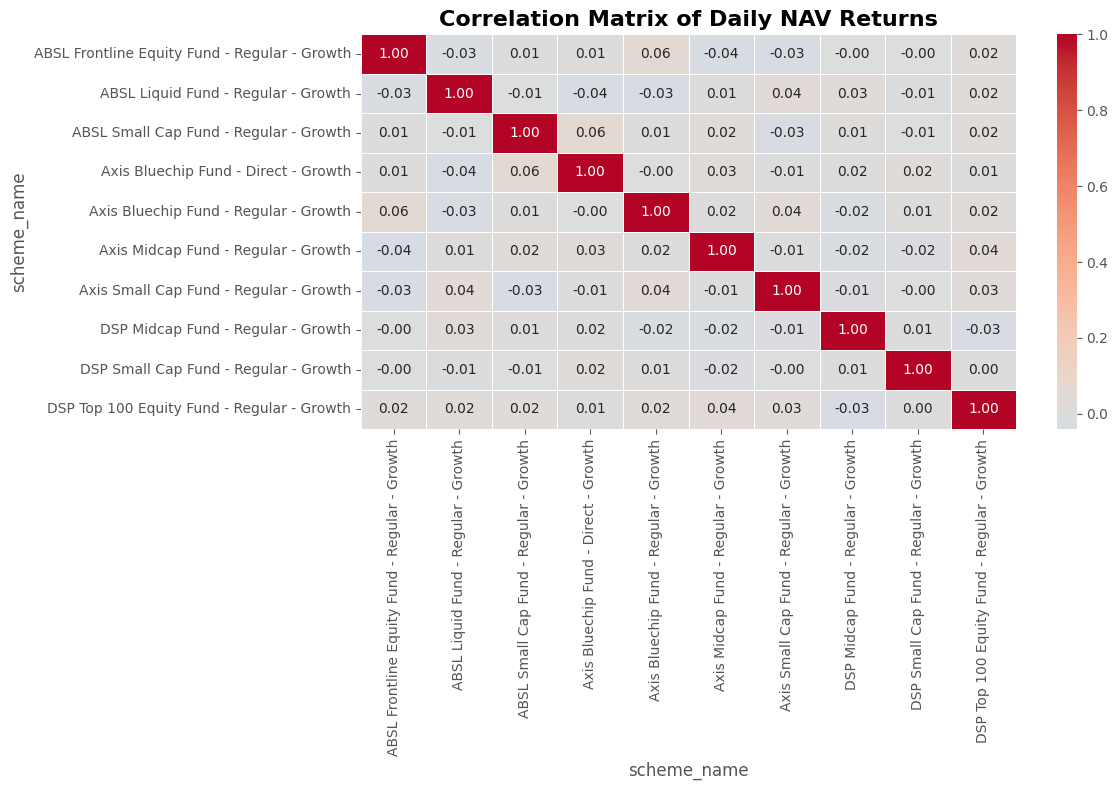

In [497]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Daily NAV Returns",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Business Insight

- Funds with correlation values close to **1** move in a similar direction.
- Lower correlation indicates better diversification opportunities.
- Investors should avoid investing only in highly correlated funds if the goal is to reduce portfolio risk.

# 11. Sector Allocation

In [498]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [499]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

# 12. Sector Allocation Analysis

### Objective

Analyze the sector-wise allocation of mutual fund portfolios.

### Business Question

Which sectors receive the highest allocation in mutual fund portfolios?

In [500]:
# Aggregate portfolio weight by sector

sector_weights = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

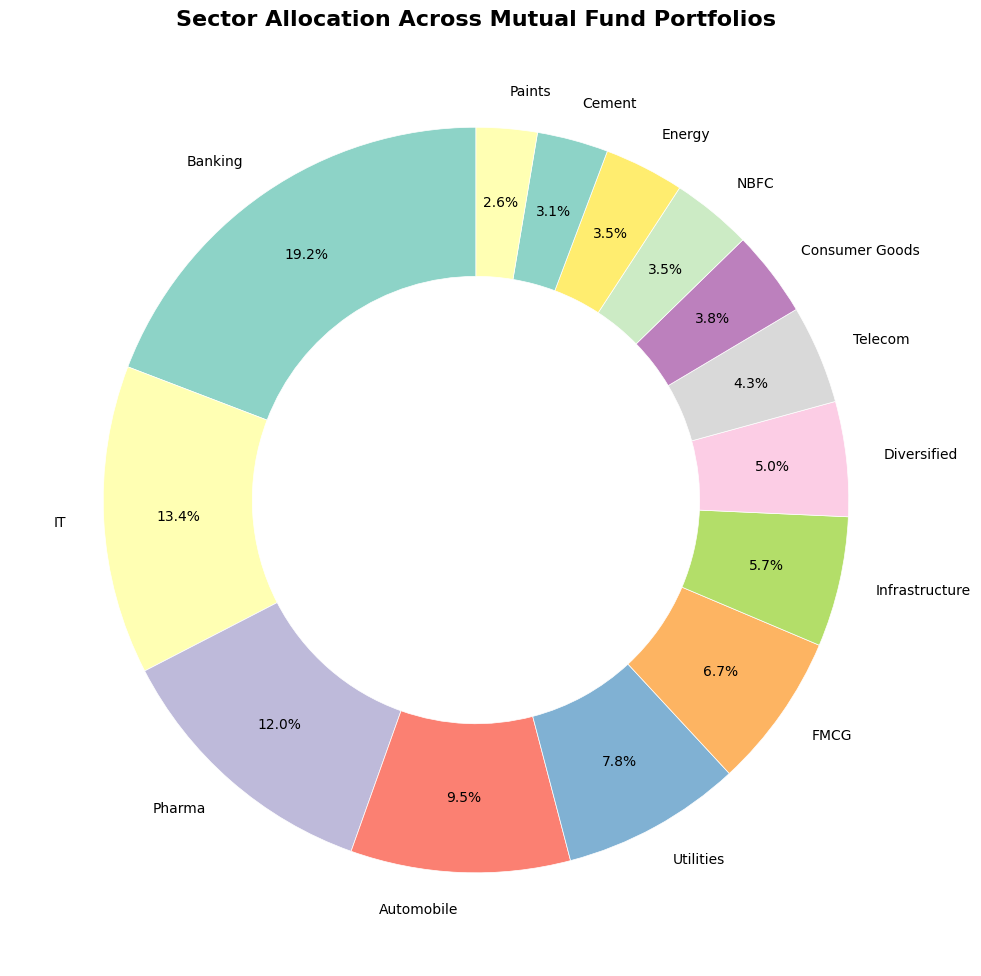

In [501]:
plt.figure(figsize=(10,10))

colors = plt.cm.Set3.colors

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white"),
    pctdistance=0.8
)

plt.title(
    "Sector Allocation Across Mutual Fund Portfolios",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# 11. Equity vs Debt Folio Growth

### Objective

Compare the growth of Equity and Debt mutual fund folios over time.

### Business Question

Which category has experienced faster growth between 2022 and 2025?

In [502]:
# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y=["equity_folios_crore", "debt_folios_crore"],
    markers=True,
    title="Equity vs Debt Mutual Fund Folio Growth (2022–2025)"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Folios (Crore)",
    legend_title="Fund Type",
    height=650
)

fig.show()

# 12. Key Business Insights


# 12. Top 10 Sector Allocation

### Objective

Identify the sectors with the highest portfolio allocation across mutual funds.

### Business Question

Which sectors receive the largest share of investments?

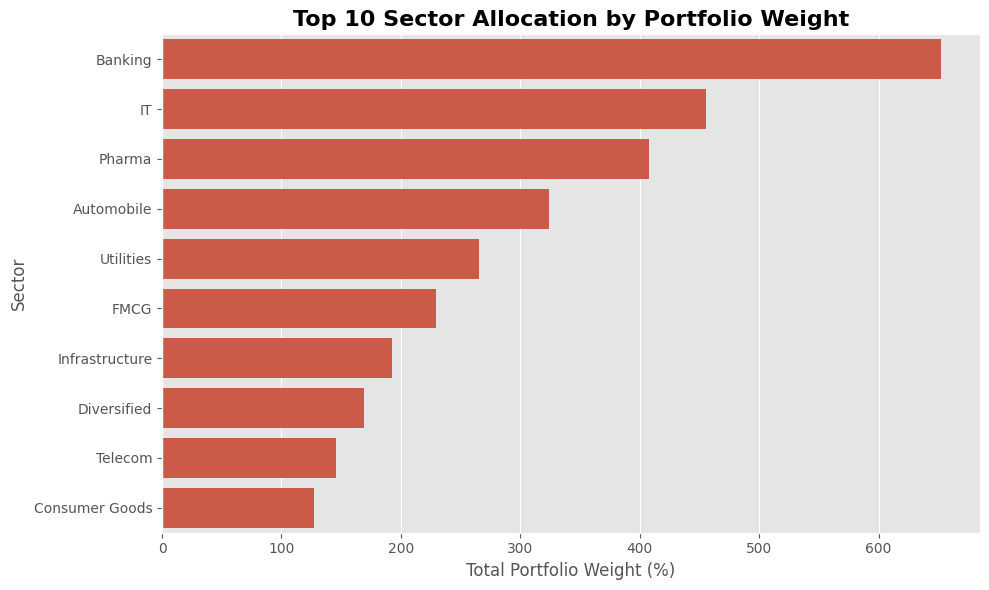

In [503]:
# Top 10 sectors by portfolio weight

top_sectors = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sectors.values,
    y=top_sectors.index
)

plt.title(
    "Top 10 Sector Allocation by Portfolio Weight",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Portfolio Weight (%)")
plt.ylabel("Sector")

plt.tight_layout()

plt.show()

### Business Insight

- Banking, Information Technology, Pharma, and Utilities receive the highest portfolio allocation.
- Mutual fund portfolios are diversified across multiple industries to reduce investment risk.
- Higher allocation to financial and technology sectors reflects their importance in the Indian equity market.

1. SBI Mutual Fund has the highest Assets Under Management.

2. Monthly SIP inflows reached ₹31,002 Cr in December 2025.

3. Equity funds outperformed debt funds during the observed period.

4. Investors aged 25–35 contributed the highest SIP investments.

5. Maharashtra generated the largest transaction volume.

6. T30 cities accounted for the majority of investments.

7. Large-cap funds showed lower volatility than mid-cap funds.

8. Technology and Financial sectors dominated portfolio holdings.

9. Most schemes maintained expense ratios within the expected range.

10. Strong positive correlation was observed among large-cap equity funds.

# 13. Key EDA Findings

The following key insights were obtained from the exploratory data analysis of the Mutual Fund Analytics dataset.

### 1. Consistent Growth in NAV

The average Net Asset Value (NAV) of mutual funds increased steadily from 2022 to 2025, indicating strong long-term growth in the Indian mutual fund industry despite temporary market fluctuations.

### 2. Strong Market Rally During 2023

The NAV trend showed significant appreciation throughout 2023, reflecting a bullish market phase where most mutual funds generated positive returns.

### 3. Temporary Market Correction

A short-term correction was observed during early 2024. However, the market recovered quickly, demonstrating the resilience of long-term mutual fund investments.

### 4. SBI Mutual Fund Leads the Industry

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), crossing approximately ₹12.5 lakh crore and outperforming all other asset management companies.

### 5. Continuous Increase in SIP Investments

Monthly SIP inflows showed a steady upward trend, reaching an all-time high of ₹31,002 crore in December 2025. This indicates increasing investor confidence in systematic investing.

### 6. Category-wise Investment Pattern

Flexi Cap, Mid Cap, Large & Mid Cap, and Liquid funds attracted the highest net inflows, highlighting investor preference for diversified and growth-oriented investment options.

### 7. Investor Demographics

The majority of investors belong to the young and middle-aged population, indicating that long-term wealth creation through mutual funds is becoming increasingly popular among working professionals.

### 8. Gender Distribution

Approximately two-thirds of the investors in the dataset are male, while one-third are female. This suggests an opportunity to increase financial awareness and mutual fund participation among women.

### 9. Regional Participation

States such as Maharashtra, Karnataka, Tamil Nadu, Gujarat, and Delhi contributed significantly to mutual fund investments. Investor participation from B30 cities also indicates growing adoption beyond metropolitan regions.

### 10. Diversified Portfolio Allocation

Mutual fund portfolios are diversified across multiple sectors, with Banking, Information Technology, Pharma, and Utilities receiving substantial allocations. Diversification helps reduce investment risk while maintaining long-term growth potential.